In this iteration, sklearn.utils.resample was used to upsample the critical class to 8,000 samples in the training set by sampling with replacement from the existing critical tickets. Unlike SMOTE, this approach does not generate synthetic samples — it simply duplicates real ones, which likely explains why it had no meaningful impact on the ROC/AUC curve. Overall accuracy remained strong, but the model once again failed to predict any English ticket as critical, reinforcing that the issue is a data problem rather than a sampling one — the model had no English critical tickets to learn from regardless of how many times the German ones were duplicated.

In [1]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("Tobi-Bueck/customer-support-tickets")

######## Run this if you want the untranslated dataset
# df = dataset["train"].to_pandas() 

######## Run this if you want the translated dataset
df = pd.read_csv("df_translated.csv")

# merge very_low → low
df.loc[df["priority"] == "very_low", "priority"] = "low"

/Users/kylebeedon/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Clean text

In [2]:
import re

def clean_text(text):
    text = text.lower()
    
    # remove common greeting prefixes at start of message
    text = re.sub(r"^(dear\s+)?(customer\s+(support|service)\s*(team)?|support\s*team)[\s,:\-]*", "", text)

    # remove generic greetings, urls, signnatures, and whitespace
    text = re.sub(r"^(hello|hi|greetings)[\s,:\-]*", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"(best regards|kind regards|sincerely).*", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [3]:
# For english, change all df's to english

# Clean Subject and Body
df["body"] = df["body"].astype(str).apply(clean_text)
df["subject"] = df["subject"].astype(str).apply(clean_text)

# Concat subject and body into one "Text"
df["text"] = df["subject"] + " " + df["body"]

# Fill na with unknown
df["version"] = df["version"].fillna("unknown").astype(str)
# I doubt version would be a reasonable predictor but we shall see

# Combine all Tags into one
tag_cols = [f"tag_{i}" for i in range(1,9)]
df["all_tags"] = df[tag_cols].fillna("").agg(" ".join, axis=1)

# Train-test split

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["priority"])
y = df["priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [5]:
X_train.head()

,subject,body,answer,type,queue,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,text,all_tags
45187,data blocking,i am reporting an unexpected data blocking. it...,"Sehr geehrte <name>, wir bedanken uns für Ihre...",Incident,Returns and Exchanges,de,unknown,Customer,Outage,Bug,Resolution,Account,NaN,NaN,NaN,data blocking i am reporting an unexpected dat...,Customer Outage Bug Resolution Account
29754,regarding the current api outage,i'm reporting an urgent issue: access to the a...,NaN,NaN,Online Communities/Social Networks,de,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,regarding the current api outage i'm reporting...,
33965,request for historical storygraph api document...,"support team, i am writing to request access t...",NaN,NaN,Books & Literature/Fiction,de,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,request for historical storygraph api document...,
27423,concern regarding data analytics tools integra...,reporting an issue with data analytics tools a...,"<name>, thank you for reaching out to us regar...",Incident,Technical Support,en,400.0,Bug,Performance,Hardware,IT,Tech Support,NaN,NaN,NaN,concern regarding data analytics tools integra...,Bug Performance Hardware IT Tech Support
18718,urgent technical assistance required,we are experiencing a technical issue due to r...,"Dear [name], we apologize for the technical is...",Incident,Technical Support,en,400.0,Bug,Performance,IT,Tech Support,NaN,NaN,NaN,NaN,urgent technical assistance required we are ex...,Bug Performance IT Tech Support


# Resample to increase number of critical tickets in train dataset

In [6]:
from sklearn.utils import resample

# Put ALL columns back into a dataframe, not just text and priority
train_df = X_train.copy()
train_df["priority"] = y_train

# Separate classes
critical = train_df[train_df["priority"] == "critical"]
other = train_df[train_df["priority"] != "critical"]

# Upsample critical
critical_upsampled = resample(
    critical,
    replace=True,
    n_samples=8000,
    random_state=42
)

# Combine + shuffle
train_balanced = pd.concat([other, critical_upsampled])
train_balanced = train_balanced.sample(frac=1, random_state=42)

# Reset X_train, y_train
X_train = train_balanced.drop(columns=["priority"])
y_train = train_balanced["priority"]

In [7]:
train_balanced.priority.value_counts()
# X_train.head()

# We now have 8000 critical tickets in our training set

priority
medium      18703
high        17540
low         11638
critical     8000
Name: count, dtype: int64

# Vectorizer

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

text_col = "text"
cat_cols = ["type", "version", "all_tags", "language"]

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=80000,
            ngram_range=(1, 3),
            stop_words="english",
            sublinear_tf=True,
            max_df=0.85,
            norm=None,
            min_df=5
        ), text_col),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Pipeline

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

pipeline.fit(X_train, y_train)
print("Training complete.")

/Users/kylebeedon/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training complete.


# Evaluation

In [10]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = pipeline.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

auc_scores = roc_auc_score(
    y_test,
    pipeline.predict_proba(X_test),
    multi_class="ovr",
    average=None,
    labels=pipeline.classes_
)

print("\nPer-class AUC (One-vs-Rest):")
for cls, score in zip(pipeline.classes_, auc_scores):
    print(f"  {cls:>10}: {score:.3f}")

=== Classification Report ===
              precision    recall  f1-score   support

    critical       0.93      0.86      0.90       383
        high       0.79      0.78      0.78      4385
         low       0.78      0.76      0.77      2910
      medium       0.77      0.79      0.78      4675

    accuracy                           0.78     12353
   macro avg       0.82      0.80      0.81     12353
weighted avg       0.78      0.78      0.78     12353


Per-class AUC (One-vs-Rest):
    critical: 0.999
        high: 0.909
         low: 0.923
      medium: 0.897


In [11]:
eval_df = X_test.copy()
eval_df["pred"] = y_pred
eval_df["actual"] = y_test

criticals = eval_df[eval_df.pred == "critical"]
criticals.language.value_counts()
# once again, all 362 predicted critical tickets are German

language
de    353
Name: count, dtype: int64

# ROC Curve

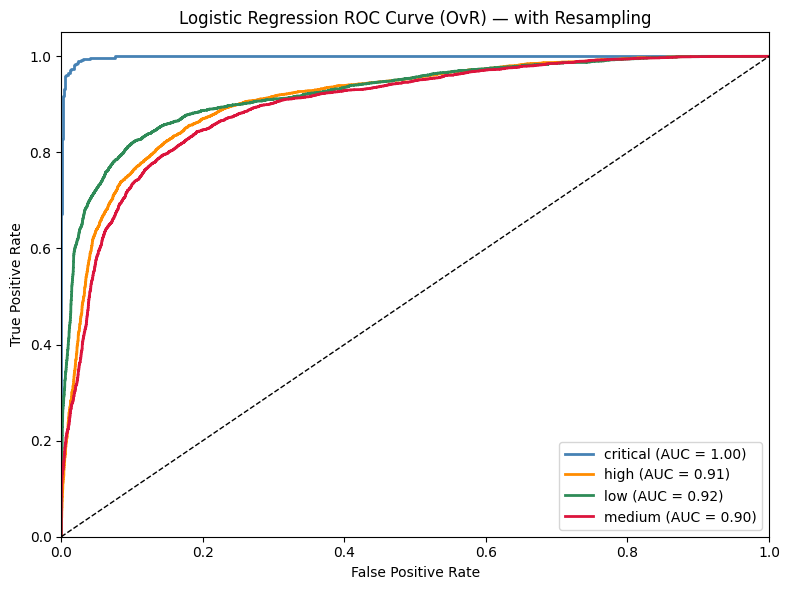

In [12]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

classes = pipeline.classes_
y_test_bin = label_binarize(y_test, classes=classes)
y_probs = pipeline.predict_proba(X_test)

colors = ["steelblue", "darkorange", "seagreen", "crimson"]
plt.figure(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve (OvR) — with Resampling")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()